<div style="
background-color:#EAEAEA;
padding:15px;
border-left:5px solid #6C757D;
border-radius:6px;">

# Master's Thesis in Advanced Physics
---

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**  
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**  
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>  
Michele Lucente <michele.lucente@unibo.it>

**Date**  
June 2026
</div>

# Core Diagnostic 1 - Potentials and Hamiltonian Scales
---

This notebook starts the Core diagnostic series. It isolates the two scalar ingredients used to build the Standard Model oscillation Hamiltonian in matter:

- the kinetic phase scale generated by the mass-squared splittings,
- the charged-current matter potential generated by coherent forward scattering on electrons.

The notebook is intentionally diagnostic rather than a pytest suite. The automated sanity checks live in `tpeanuts.core.common.test.test1_potential`; here we keep the plots and physical interpretation.

---

## Table of Contents

| # | Section |
|---|---------|
| [0](#0.-Theory-Background) | **Theory Background**: natural-unit Hamiltonian, kinetic term, matter potential, dimensionless scaling |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Paths and Configuration** |
| [3](#3.-Potential) | **Potential**: matter scale, kinetic scale, and relative size |
| [4](#4.-PMNS-Mixing-Matrix) | **PMNS Mixing Matrix**: flavour content, unitarity, CP phase |
| [5](#5.-Hamiltonian) | **Hamiltonian**: reduced/flavour bases, matter and kinetic structure |
| [?](#6.-Summary) | **Summary** |


## 0. Theory Background

### 0.1 Neutrinos, Flavour Basis, and Mass Basis

Neutrinos are electrically neutral leptons that participate in weak interactions. In the Standard Model active sector there are three weak-interaction flavours,

$$
\nu_e,\qquad \nu_\mu,\qquad \nu_\tau,
$$

associated with the charged leptons $e$, $\mu$, and $\tau$. These states define the **flavour basis**. It is the basis selected by production and detection through charged-current weak interactions: an electron neutrino is the state produced together with an electron or positron, and analogously for muon and tau flavours.

Independently, free propagation is most naturally described in terms of states with definite masses,

$$
\nu_1,\qquad \nu_2,\qquad \nu_3,
$$

which define the **mass basis**. Each mass eigenstate has a mass $m_i$, and oscillation phases are governed by the mass-squared differences $\Delta m_{ij}^2=m_i^2-m_j^2$. This notebook uses both bases: first as separate physical descriptions, and then through the PMNS mixing matrix introduced below.

---

### 0.2 Kinetic Term

Only mass-squared differences affect oscillations. Taking $m_1^2$ as the reference, the kinetic diagonal entries are

$$
k_i = \frac{\Delta m_{i1}^2}{2E},
$$

with $\Delta m_{11}^2=0$, $\Delta m_{21}^2$ the solar splitting, and $\Delta m_{31}^2$ or $\Delta m_{32}^2$ the atmospheric splitting depending on ordering conventions. In `tpeanuts`, `kinetic_potential` returns the dimensionless version

$$
K_i = L_0\,\frac{\Delta m_{i1}^2}{2E\,\hbar c},
$$

where $L_0$ is the evolution scale used to write the coordinate as $x=L/L_0$. The code accepts $\Delta m^2$ in eV$^2$, $E$ in MeV, and applies the $10^{-12}$ conversion from eV$^2$ to MeV$^2$.

---

### 0.3 Matter Potential

The charged-current matter potential is

$$
V_{CC}=\sqrt{2}\,G_F\,n_e,
$$

where $G_F$ is the Fermi constant and $n_e$ is the electron number density. In this codebase, electron density is passed as a molar density in mol/cm$^3$. The dimensionless potential used inside the Hamiltonian is

$$
A = \pm L_0\,\sqrt{2}\,G_F\,N_A\,10^6\,(\hbar c)^2\,n_e,
$$

with the plus sign for neutrinos and the minus sign for antineutrinos. The factor $N_A10^6$ converts mol/cm$^3$ to particles/m$^3$.

---

### 0.4 PMNS Mixing Matrix

The flavour and mass bases are connected by the Pontecorvo-Maki-Nakagawa-Sakata (PMNS) matrix,

$$
|\nu_\alpha\rangle = \sum_i U_{\alpha i}^* |\nu_i\rangle,
\qquad
|\nu_i\rangle = \sum_\alpha U_{\alpha i}|\nu_\alpha\rangle,
$$

where $\alpha=e,\mu,\tau$ labels flavour eigenstates and $i=1,2,3$ labels mass eigenstates. In the Standard Model three-flavour sector, `tpeanuts` uses the product convention

$$
U = R_{23}\,\Delta\,R_{13}\,\Delta^\dagger\,R_{12},
\qquad
\Delta = \mathrm{diag}(1,1,e^{i\delta_{CP}}).
$$



The three real angles $\theta_{ij}$ parametrize rotations between pairs of mass/flavour directions:

- $\theta_{12}$ is the **solar mixing angle**. It controls the mixing between the first and second neutrino states and dominates solar-neutrino oscillations governed by $\Delta m^2_{21}$.
- $\theta_{13}$ is the **reactor mixing angle**. It controls the coupling of the electron flavour to the third mass state, through $|U_{e3}|^2=\sin^2\theta_{13}$, and is measured very precisely by reactor experiments.
- $\theta_{23}$ is the **atmospheric mixing angle**. It controls the mixing between the muon and tau sectors and is central to atmospheric and long-baseline accelerator oscillations.

The real rotations are defined as

$$
R_{12}(\theta_{12})=
\begin{pmatrix}
 c_{12} & s_{12} & 0 \\
-s_{12} & c_{12} & 0 \\
0 & 0 & 1
\end{pmatrix},
$$

$$
R_{13}(\theta_{13})=
\begin{pmatrix}
 c_{13} & 0 & s_{13} \\
0 & 1 & 0 \\
-s_{13} & 0 & c_{13}
\end{pmatrix},
$$

$$
R_{23}(\theta_{23})=
\begin{pmatrix}
1 & 0 & 0 \\
0 & c_{23} & s_{23} \\
0 & -s_{23} & c_{23}
\end{pmatrix},
$$

where $c_{ij}=\cos\theta_{ij}$ and $s_{ij}=\sin\theta_{ij}$. The CP phase is inserted through

$$
\Delta(\delta_{CP})=
\begin{pmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & e^{i\delta_{CP}}
\end{pmatrix}.
$$

The reduced matrix used internally in the kinetic Hamiltonian is

$$
U_{\rm red}=R_{13}R_{12}.
$$

The measurable flavour content of a mass eigenstate is given by the doubly-stochastic matrix

$$
P_{\alpha i}^{\rm vac}=|U_{\alpha i}|^2,
\qquad
\sum_i |U_{\alpha i}|^2=1,
\qquad
\sum_\alpha |U_{\alpha i}|^2=1.
$$

The electron row has a particularly transparent interpretation:

$$
|U_{e1}|^2=c_{13}^2c_{12}^2,
\qquad
|U_{e2}|^2=c_{13}^2s_{12}^2,
\qquad
|U_{e3}|^2=s_{13}^2.
$$

These identities connect the PMNS matrix directly to solar-neutrino phenomenology: $\theta_{12}$ controls the $\nu_e$ sharing between $\nu_1$ and $\nu_2$, while the small reactor angle $\theta_{13}$ controls the $\nu_3$ electron component.

---

### 0.5 Standard Oscillation Parameters: NuFIT 6.0

The numerical benchmarks used in modern three-flavour oscillation studies are usually taken from global fits. The most recent NuFIT release found for this notebook is **NuFIT 6.0**, based on global oscillation data available up to **September 2024**. The corresponding analysis is published as *NuFit-6.0: Updated global analysis of three-flavor neutrino oscillations* by Esteban, Gonzalez-Garcia, Maltoni, Martinez-Soler, Pinheiro, and Schwetz.

The NuFIT collaboration provides best-fit values and allowed regions for the six standard oscillation parameters:

$$
\theta_{12},\quad \theta_{13},\quad \theta_{23},\quad
\delta_{CP},\quad \Delta m^2_{21},\quad \Delta m^2_{3\ell}.
$$

The parameter $\Delta m^2_{3\ell}$ follows the usual convention: $\ell=1$ for normal ordering and $\ell=2$ for inverted ordering. NuFIT 6.0 reports that $\theta_{12}$, $\theta_{13}$, $\Delta m^2_{21}$, and $|\Delta m^2_{3\ell}|$ are comparatively well constrained, while $\theta_{23}$ still has an octant ambiguity and the preferred values of $\delta_{CP}$ depend on the mass ordering and data combination.

In `tpeanuts`, preset names such as `_SM_NUFIT52_NO` encode a concrete parameter set used to build `OscillationParameters`. If a newer NuFIT preset is added to the package, this notebook can be updated by changing the preset used in the configuration cells without changing the mathematical definitions above.

---

### 0.6 CP Phase and the Jarlskog Invariant

CP violation in three-flavour oscillations is controlled by the rephasing-invariant Jarlskog quantity

$$
J = \mathrm{Im}\left(U_{e1}U_{\mu2}U_{e2}^*U_{\mu1}^*\right)
  = \frac{1}{8}\sin2\theta_{12}\sin2\theta_{13}\sin2\theta_{23}\cos\theta_{13}\sin\delta_{CP}.
$$

This invariant vanishes when $\delta_{CP}=0,\pi$, when any mixing angle needed to connect all three flavours is zero, or when only CP-even vacuum projectors $|U_{\alpha i}|^2$ are considered. The full complex matrix changes under $\delta_{CP}\to-\delta_{CP}$, while the vacuum flavour projector remains unchanged under complex conjugation.

---

### 0.7 Coherent Evolution and Dimensionless Hamiltonian

Coherent neutrino propagation is described by a Schr?dinger-like equation,

$$
 i\frac{d}{dL}\,\nu_f(L) = H_f(L)\,\nu_f(L),
$$

where $L$ is the propagation distance and $\nu_f=(\nu_e,\nu_\mu,\nu_\tau)^T$. In vacuum, the Hamiltonian is generated by mass splittings and mixing. In ordinary matter, electron neutrinos receive an additional charged-current contribution from coherent forward scattering on electrons; the neutral-current contribution is common to all active flavours and can be dropped because it adds only a global phase.

In the flavour basis, the Standard Model Hamiltonian can be written as

$$
H_f = U\,\frac{1}{2E}\,\mathrm{diag}(m_1^2,m_2^2,m_3^2)\,U^\dagger
    + \mathrm{diag}(V_{CC},0,0),
$$

up to subtraction of an irrelevant multiple of the identity. The numerical evolutors work with a dimensionless coordinate $x=L/L_0$, so matrix exponentials use a dimensionless Hamiltonian,

$$
S(L) = \exp\left[-i\,H_f\,L\right]
     = \exp\left[-i\,\mathcal{H}_f\,x\right],
\qquad
\mathcal{H}_f=L_0H_f.
$$

Both `matter_potential` and `kinetic_potential` include the same $L_0$ factor. Changing `evolution_scale_m` rescales both terms linearly, provided the propagation coordinate is rescaled consistently.

For the Standard Model active sector, the reduced Hamiltonian used by the core modules is assembled from

$$
\mathcal{H}_\mathrm{kin}=U_\mathrm{red}\,\mathrm{diag}(K_1,K_2,K_3)\,U_\mathrm{red}^\dagger,
\qquad
\mathcal{H}_\mathrm{mat}=\mathrm{diag}(A,0,0).
$$

This block collects the coherent-evolution equation, the dimensionless scaling, and the bridge from the scalar potentials to the Hamiltonian construction used later in the notebook.

---

### 0.8 Reduced and Flavour-Basis Hamiltonians

The Standard Model three-flavour Hamiltonian implemented in `tpeanuts.core.common.hamiltonian` is built in two closely related bases. In the reduced basis, the kinetic piece is

$$
\mathcal{H}_{\rm kin}^{\rm red}
= U_{\rm red}\,\mathrm{diag}(K_1,K_2,K_3)\,U_{\rm red}^{T},
$$

where $K_i=L_0\Delta m_i^2/(2E\hbar c)$ are the dimensionless kinetic eigenvalues. The matter piece is diagonal in the electron flavour direction,

$$
\mathcal{H}_{\rm mat}^{\rm red}=\mathrm{diag}(A,0,0),
$$

with $A$ the dimensionless charged-current matter potential. The reduced Hamiltonian is therefore

$$
\mathcal{H}_{\rm red}=\mathcal{H}_{\rm kin}^{\rm red}+\mathcal{H}_{\rm mat}^{\rm red}.
$$

The full flavour-basis Hamiltonian used by the propagation layers is obtained by the same PMNS basis transform implemented in the PMNS object,

$$
\mathcal{H}_{f}
= R_{23}\Delta\,\mathcal{H}_{\rm red}\,\Delta^\dagger R_{23}^{T}.
$$

For antineutrinos, the PMNS convention is complex conjugated and the matter potential changes sign. In the absence of matter, the kinetic Hamiltonian is Hermitian and its eigenvalue splittings scale as $1/E$; in matter, the electron-flavour diagonal entry shifts by $A$.

---

### References

- L. Wolfenstein, "Neutrino oscillations in matter", *Physical Review D* **17**, 2369 (1978).
- S. P. Mikheyev and A. Yu. Smirnov, "Resonant amplification of neutrino oscillations in matter and solar-neutrino spectroscopy", *Il Nuovo Cimento C* **9**, 17 (1986).
- C. Giunti and C. W. Kim, *Fundamentals of Neutrino Physics and Astrophysics*, Oxford University Press (2007).
- Particle Data Group, "Neutrino Masses, Mixing, and Oscillations", *Review of Particle Physics*.


## 1. Libraries


In [49]:
import math

import numpy as np
import torch
import matplotlib.pyplot as plt

import tpeanuts.util.constant as constant
from tpeanuts.core.common.potential import matter_potential, kinetic_potential
from tpeanuts.core.common.hamiltonian import (
    hamiltonian_flavour,
    hamiltonian_kinetic_reduced,
    hamiltonian_matter_reduced,
    hamiltonian_reduced,
    kinetic_mass_vector,
)
from tpeanuts.core.common.oscillation import OscillationParameters
from tpeanuts.core.common.pmns import PMNSParams
from tpeanuts.core.SM.pmns import PMNS_SM
from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import save_and_show, to_numpy
from tpeanuts.util.context import RuntimeContext

print(f"Torch {torch.__version__}")


Torch 2.3.1


## 2. Paths and Configuration

### 2.1 Paths

`load_notebook_config()` resolves the repository root, applies the shared plotting style, and provides the common output root. The output directory is built from the notebook path relative to `notebooks/`, excluding the notebook filename: `diagnostic/core`.

**Expected results:** the printed paths should point to the local TPeanuts repository and to an output directory ending in `diagnostic/core`.


In [50]:
config = load_notebook_config()
ctx = RuntimeContext.resolve(config.device, config.dtype)
OUTPUT_DIR = config.output_dir("diagnostic", "core")

print(f"Package dir : {config.package_dir}")
print(f"Output root : {config.output_root}")
print(f"Output dir  : {OUTPUT_DIR}")
print(f"Device      : {ctx.device}   dtype: {ctx.dtype}")


Package dir : G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Output root : v:\output
Output dir  : v:\output\diagnostic\core
Device      : cpu   dtype: torch.float64


### 2.2 Configuration

The diagnostic grids are deliberately broad enough to show scaling laws rather than to model a single experiment. Electron densities are shown in mol/cm$^3$, which is the unit expected by `matter_potential`. Energies are shown in MeV, which is the unit expected by `kinetic_potential`.

| Parameter | Value | Description |
|-----------|-------|-------------|
| $L_0$ | $R_\oplus$ by default | Evolution scale used to make the Hamiltonian dimensionless |
| $n_e$ grid | $0$ to $15$ mol/cm$^3$ | Representative range for matter-potential scaling |
| $E$ grid | $10$ to $10^6$ MeV | Wide range for kinetic $1/E$ scaling |
| $\Delta m^2_{21}$ | $7.42\times10^{-5}$ eV$^2$ | Solar mass splitting used in examples |
| $\Delta m^2_{3\ell}$ | $2.517\times10^{-3}$ eV$^2$ | Atmospheric mass splitting used in examples |
| Reference density | $5$ mol/cm$^3$ | Used for matter-to-kinetic comparison |


In [51]:
EVOLUTION_SCALE_M = constant.R_E
MASS_SPLITTINGS_EV2 = torch.tensor([0.0, 7.42e-5, 2.517e-3], device=ctx.device, dtype=ctx.dtype)
ENERGY_GRID_MEV = torch.logspace(1.0, 6.0, 500, device=ctx.device, dtype=ctx.dtype)
DENSITY_GRID_MOLCM3 = torch.linspace(0.0, 15.0, 300, device=ctx.device, dtype=ctx.dtype)
REFERENCE_DENSITY_MOLCM3 = torch.tensor(5.0, device=ctx.device, dtype=ctx.dtype)

print(f"Evolution scale L0 : {EVOLUTION_SCALE_M:.6e} m")
print(f"Mass splittings    : {MASS_SPLITTINGS_EV2.detach().cpu().numpy()} eV^2")
print(f"Energy grid        : {float(ENERGY_GRID_MEV[0]):.1f} -- {float(ENERGY_GRID_MEV[-1]):.1e} MeV")
print(f"Density grid       : {float(DENSITY_GRID_MOLCM3[0]):.1f} -- {float(DENSITY_GRID_MOLCM3[-1]):.1f} mol/cm^3")


Evolution scale L0 : 6.371000e+06 m
Mass splittings    : [0.000e+00 7.420e-05 2.517e-03] eV^2
Energy grid        : 10.0 -- 1.0e+06 MeV
Density grid       : 0.0 -- 15.0 mol/cm^3


### 2.3 Helpers

No notebook-specific helper functions are required. The notebook uses `to_numpy` and `save_and_show` from `tpeanuts.notebooks.notebooks_helper`.


## 3. Potential

### 3.1 Matter Potential versus Electron Density

The charged-current matter potential is linear in electron density and changes sign for antineutrinos. The plot compares the full-precision factor used by default with the legacy rounded prefactor retained for validation against the original Peanuts implementation.

**Expected results:** both neutrino curves grow linearly with $n_e$, antineutrinos have exactly the opposite sign, and the legacy/full-precision relative difference is small and nearly constant wherever $n_e>0$.


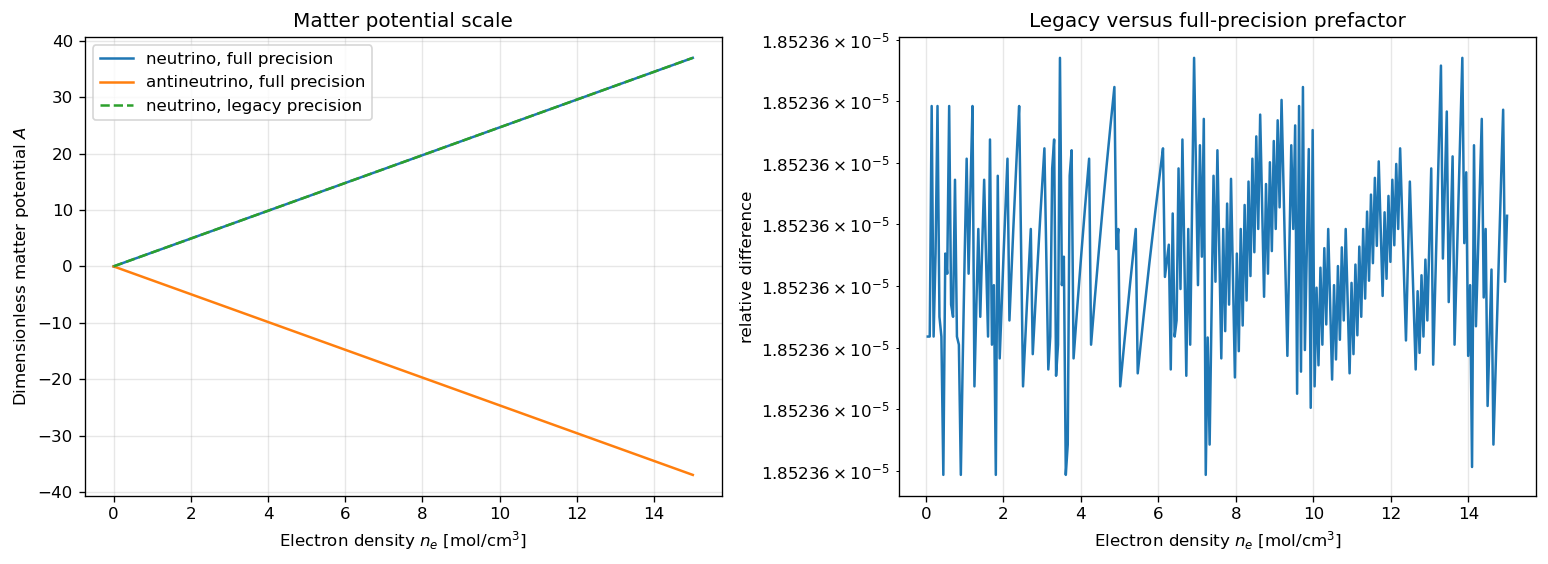

v:\output\diagnostic\core\diagnostic1_fig3_1_matter_potential_density.png
max relative legacy/full difference: 1.852358e-05
V(n_e=5 mol/cm^3): 1.232129e+01


In [52]:
V_nu = matter_potential(DENSITY_GRID_MOLCM3, antinu=False)
V_anti = matter_potential(DENSITY_GRID_MOLCM3, antinu=True)
V_nu_legacy = matter_potential(DENSITY_GRID_MOLCM3, antinu=False, legacy_precision=True)

rel_diff = torch.zeros_like(V_nu)
mask = torch.abs(V_nu) > 0
rel_diff[mask] = torch.abs((V_nu_legacy[mask] - V_nu[mask]) / V_nu[mask])

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))
axes[0].plot(to_numpy(DENSITY_GRID_MOLCM3), to_numpy(V_nu), label="neutrino, full precision")
axes[0].plot(to_numpy(DENSITY_GRID_MOLCM3), to_numpy(V_anti), label="antineutrino, full precision")
axes[0].plot(to_numpy(DENSITY_GRID_MOLCM3), to_numpy(V_nu_legacy), "--", label="neutrino, legacy precision")
axes[0].set_xlabel(r"Electron density $n_e$ [mol/cm$^3$]")
axes[0].set_ylabel(r"Dimensionless matter potential $A$")
axes[0].set_title("Matter potential scale")
axes[0].legend()

axes[1].plot(to_numpy(DENSITY_GRID_MOLCM3[1:]), to_numpy(rel_diff[1:]))
axes[1].set_xlabel(r"Electron density $n_e$ [mol/cm$^3$]")
axes[1].set_ylabel("relative difference")
axes[1].set_title("Legacy versus full-precision prefactor")
axes[1].set_yscale("log")

fig.tight_layout()
save_and_show("diagnostic1_fig3_1_matter_potential_density.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print(f"max relative legacy/full difference: {float(torch.max(rel_diff)):.6e}")
print(f"V(n_e=5 mol/cm^3): {float(matter_potential(REFERENCE_DENSITY_MOLCM3, antinu=False)):.6e}")


### 3.2 Kinetic Potential versus Energy

The kinetic entries scale as $K_i\propto\Delta m_i^2/E$. The first entry is zero because the Hamiltonian is written in terms of mass-squared differences relative to $m_1^2$.

**Expected results:** $K_{21}$ and $K_{3\ell}$ fall as $1/E$ on the log-log plot, and the atmospheric term stays larger than the solar term by approximately $\Delta m^2_{3\ell}/\Delta m^2_{21}$.


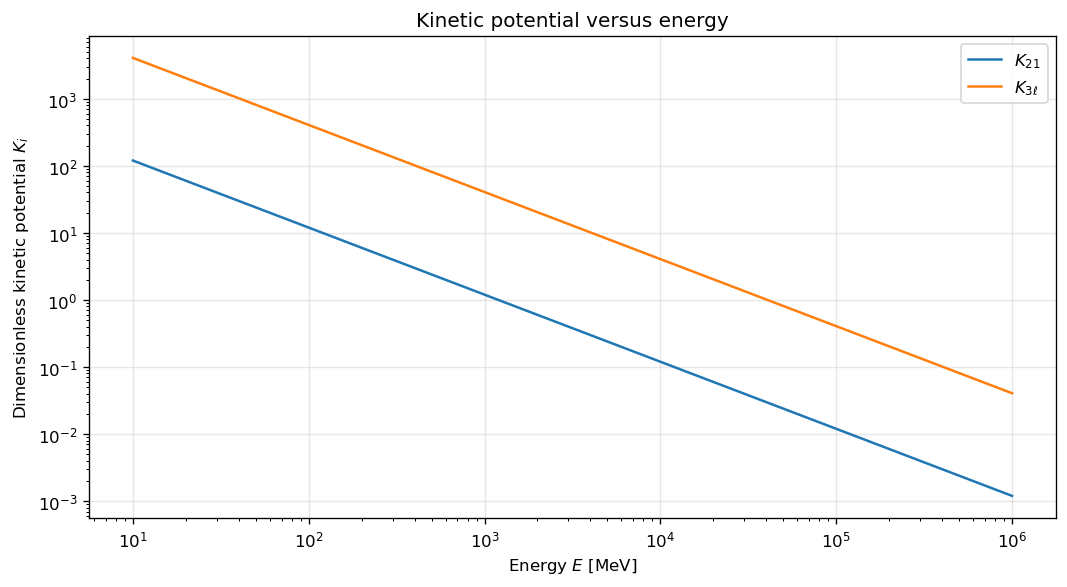

v:\output\diagnostic\core\diagnostic1_fig3_2_kinetic_potential_energy.png
median K_3l/K_21 ratio: 33.921833
Dm3l/Dm21 ratio       : 33.921833


In [53]:
K_GRID = kinetic_potential(MASS_SPLITTINGS_EV2, ENERGY_GRID_MEV)
ratio_31_21 = K_GRID[:, 2] / K_GRID[:, 1]

fig, ax = plt.subplots(figsize=(9.0, 5.0))
ax.loglog(to_numpy(ENERGY_GRID_MEV), to_numpy(K_GRID[:, 1]), label=r"$K_{21}$")
ax.loglog(to_numpy(ENERGY_GRID_MEV), to_numpy(K_GRID[:, 2]), label=r"$K_{3\ell}$")
ax.set_xlabel(r"Energy $E$ [MeV]")
ax.set_ylabel(r"Dimensionless kinetic potential $K_i$")
ax.set_title("Kinetic potential versus energy")
ax.legend()
fig.tight_layout()
save_and_show("diagnostic1_fig3_2_kinetic_potential_energy.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print(f"median K_3l/K_21 ratio: {float(torch.median(ratio_31_21)):.6f}")
print(f"Dm3l/Dm21 ratio       : {float(MASS_SPLITTINGS_EV2[2] / MASS_SPLITTINGS_EV2[1]):.6f}")


### 3.3 Matter-to-Kinetic Scale Comparison

The relative size $|A/K_{3\ell}|$ gives a compact diagnostic of when matter effects can compete with the atmospheric kinetic scale. Since $A$ is independent of energy for fixed density while $K_{3\ell}\propto1/E$, the ratio grows linearly with energy.

**Expected results:** the curve is a straight line of slope $+1$ on a log-log plot. The crossing $|A/K_{3\ell}|=1$ marks the energy where the matter scale and atmospheric kinetic scale are comparable for the chosen density.


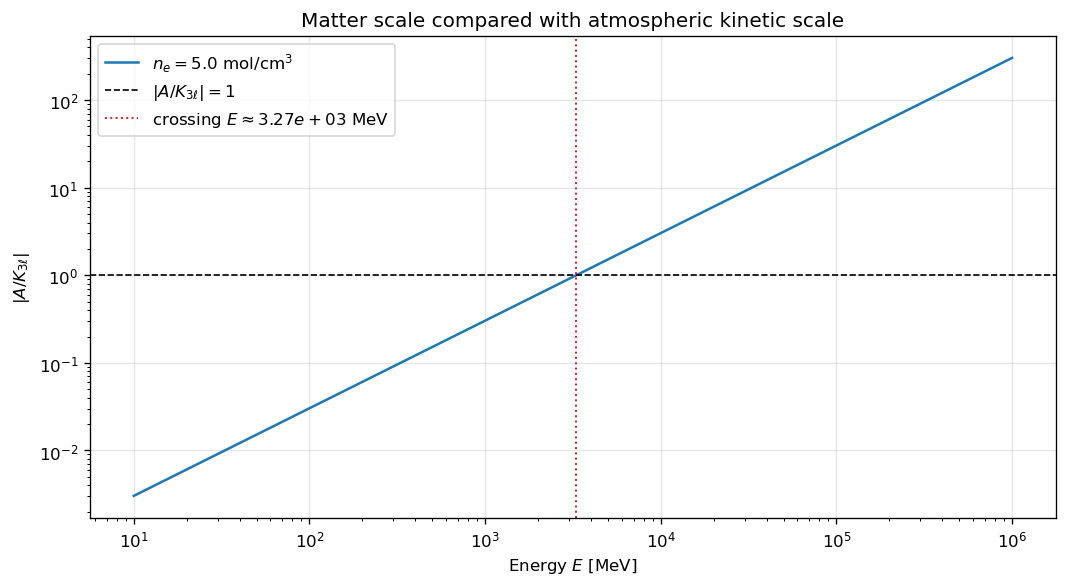

v:\output\diagnostic\core\diagnostic1_fig3_3_matter_to_kinetic_ratio.png
Reference density       : 5.000 mol/cm^3
Approximate crossing E  : 3.273634e+03 MeV
ratio at 1 GeV          : 3.032366e-01


In [54]:
A_REF = matter_potential(REFERENCE_DENSITY_MOLCM3, antinu=False)
K_3L = kinetic_potential(MASS_SPLITTINGS_EV2[2], ENERGY_GRID_MEV)
RATIO_A_K = torch.abs(A_REF / K_3L)

cross_idx = torch.argmin(torch.abs(torch.log10(RATIO_A_K)))
cross_energy = ENERGY_GRID_MEV[cross_idx]

fig, ax = plt.subplots(figsize=(9.0, 5.0))
ax.loglog(to_numpy(ENERGY_GRID_MEV), to_numpy(RATIO_A_K), label=rf"$n_e={float(REFERENCE_DENSITY_MOLCM3):.1f}$ mol/cm$^3$")
ax.axhline(1.0, color="black", linestyle="--", linewidth=1.0, label=r"$|A/K_{3\ell}|=1$")
ax.axvline(float(cross_energy), color="C3", linestyle=":", linewidth=1.2, label=rf"crossing $E\approx{float(cross_energy):.2e}$ MeV")
ax.set_xlabel(r"Energy $E$ [MeV]")
ax.set_ylabel(r"$|A/K_{3\ell}|$")
ax.set_title("Matter scale compared with atmospheric kinetic scale")
ax.legend()
fig.tight_layout()
save_and_show("diagnostic1_fig3_3_matter_to_kinetic_ratio.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print(f"Reference density       : {float(REFERENCE_DENSITY_MOLCM3):.3f} mol/cm^3")
print(f"Approximate crossing E  : {float(cross_energy):.6e} MeV")
print(f"ratio at 1 GeV          : {float(torch.abs(A_REF / kinetic_potential(MASS_SPLITTINGS_EV2[2], torch.tensor(1000.0, device=ctx.device, dtype=ctx.dtype)))):.6e}")


### 3.4 Evolution-Scale Linearity

Both scalar potentials are dimensionless because they include the same evolution scale $L_0$. This plot verifies the purely linear dependence on $L_0$ for a fixed density, energy, and mass splitting.

**Expected results:** normalizing by the value at $L_0=R_\oplus$ collapses the matter and kinetic curves onto the same straight line, equal to $L_0/R_\oplus$.


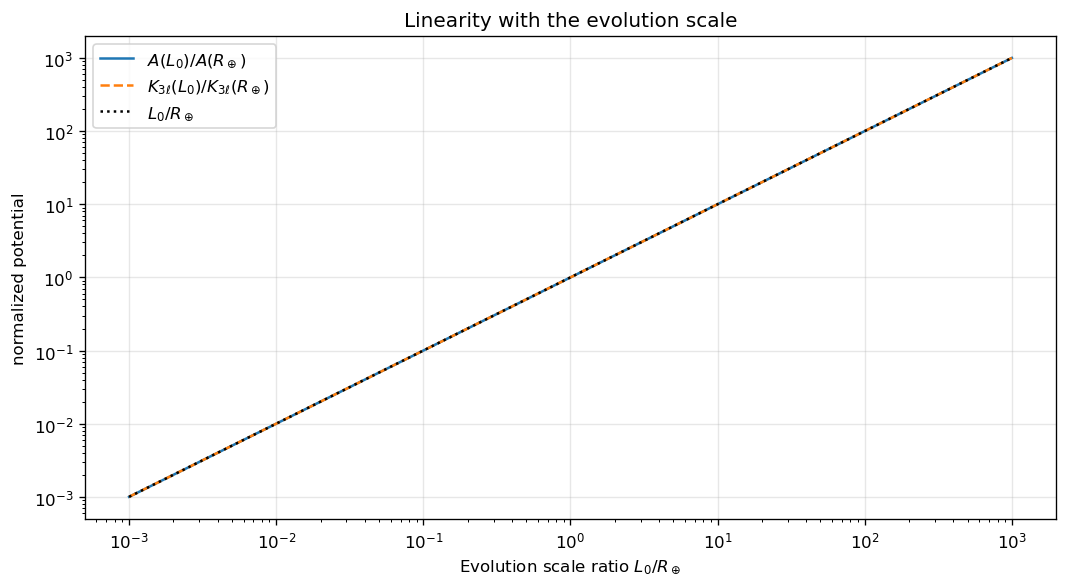

v:\output\diagnostic\core\diagnostic1_fig3_4_evolution_scale_linearity.png
A scale check max error: 1.137e-13
K scale check max error: 2.274e-13


In [55]:
scale_factors = torch.logspace(-3, 3, 200, device=ctx.device, dtype=ctx.dtype)
scales_m = scale_factors * constant.R_E

A_scales = matter_potential(REFERENCE_DENSITY_MOLCM3, antinu=False, evolution_scale_m=scales_m)
K_scales = kinetic_potential(MASS_SPLITTINGS_EV2[2], torch.tensor(1000.0, device=ctx.device, dtype=ctx.dtype), evolution_scale_m=scales_m)
A_default = matter_potential(REFERENCE_DENSITY_MOLCM3, antinu=False)
K_default = kinetic_potential(MASS_SPLITTINGS_EV2[2], torch.tensor(1000.0, device=ctx.device, dtype=ctx.dtype))

fig, ax = plt.subplots(figsize=(9.0, 5.0))
ax.loglog(to_numpy(scale_factors), to_numpy(A_scales / A_default), label=r"$A(L_0)/A(R_\oplus)$")
ax.loglog(to_numpy(scale_factors), to_numpy(K_scales / K_default), "--", label=r"$K_{3\ell}(L_0)/K_{3\ell}(R_\oplus)$")
ax.loglog(to_numpy(scale_factors), to_numpy(scale_factors), ":", color="black", label=r"$L_0/R_\oplus$")
ax.set_xlabel(r"Evolution scale ratio $L_0/R_\oplus$")
ax.set_ylabel("normalized potential")
ax.set_title("Linearity with the evolution scale")
ax.legend()
fig.tight_layout()
save_and_show("diagnostic1_fig3_4_evolution_scale_linearity.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print(f"A scale check max error: {float(torch.max(torch.abs(A_scales / A_default - scale_factors))):.3e}")
print(f"K scale check max error: {float(torch.max(torch.abs(K_scales / K_default - scale_factors))):.3e}")


## 4. PMNS Mixing Matrix

### 4.1 Flavour Content $|U_{\alpha i}|^2$

The heatmap below shows the flavour composition of each mass eigenstate. Rows are flavour states and columns are mass states. This is the most direct visual interpretation of the PMNS matrix because oscillation probabilities and decohered fluxes depend on $|U_{\alpha i}|^2$.

**Expected results:** each row and each column sums to one. The electron row is dominated by $\nu_1$ and $\nu_2$, while $|U_{e3}|^2$ is small because $\theta_{13}$ is small.


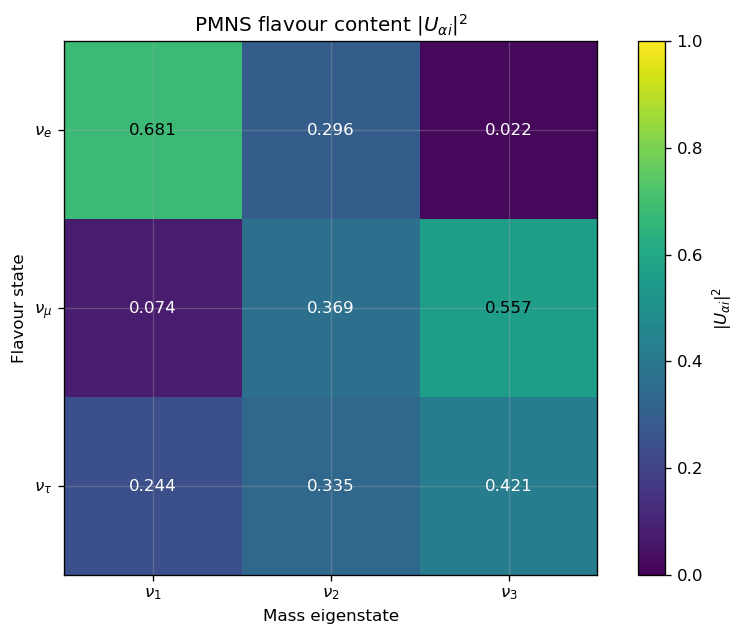

v:\output\diagnostic\core\diagnostic1_fig4_1_pmns_flavour_content.png
Row sums   : tensor([1.000000e+00, 1.000000e+00, 1.000000e+00], dtype=torch.float64)
Column sums: tensor([1.000000e+00, 1.000000e+00, 1.000000e+00], dtype=torch.float64)
Oscillation preset: _SM_NUFIT52_NO (NO)


In [56]:
oscillation = OscillationParameters.from_preset(context=ctx, antinu=False)
pmns = oscillation.pmns
U = pmns.pmns_matrix()
P_vac = pmns.vacuum_flavour_projector()

flavour_labels = [r"$\nu_e$", r"$\nu_\mu$", r"$\nu_\tau$"]
mass_labels = [r"$\nu_1$", r"$\nu_2$", r"$\nu_3$"]

fig, ax = plt.subplots(figsize=(7.2, 5.4))
im = ax.imshow(to_numpy(P_vac), vmin=0.0, vmax=1.0, cmap="viridis")
fig.colorbar(im, ax=ax, label=r"$|U_{\alpha i}|^2$")
ax.set_xticks(range(3), mass_labels)
ax.set_yticks(range(3), flavour_labels)
ax.set_xlabel("Mass eigenstate")
ax.set_ylabel("Flavour state")
ax.set_title(r"PMNS flavour content $|U_{\alpha i}|^2$")
for i in range(3):
    for j in range(3):
        value = float(P_vac[i, j])
        ax.text(j, i, f"{value:.3f}", ha="center", va="center", color="white" if value < 0.55 else "black")
fig.tight_layout()
save_and_show("diagnostic1_fig4_1_pmns_flavour_content.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print("Row sums   :", P_vac.sum(dim=1))
print("Column sums:", P_vac.sum(dim=0))
print(f"Oscillation preset: {oscillation.preset_name} ({oscillation.ordering})")


### 4.2 Row and Column Normalization

The PMNS matrix is unitary, so the squared-modulus matrix is doubly stochastic. Row sums represent the total mass-eigenstate content of each flavour state; column sums represent the total flavour content of each mass eigenstate.

**Expected results:** all bars should be equal to one within numerical precision. Deviations would indicate a loss of unitarity or an inconsistent matrix convention.


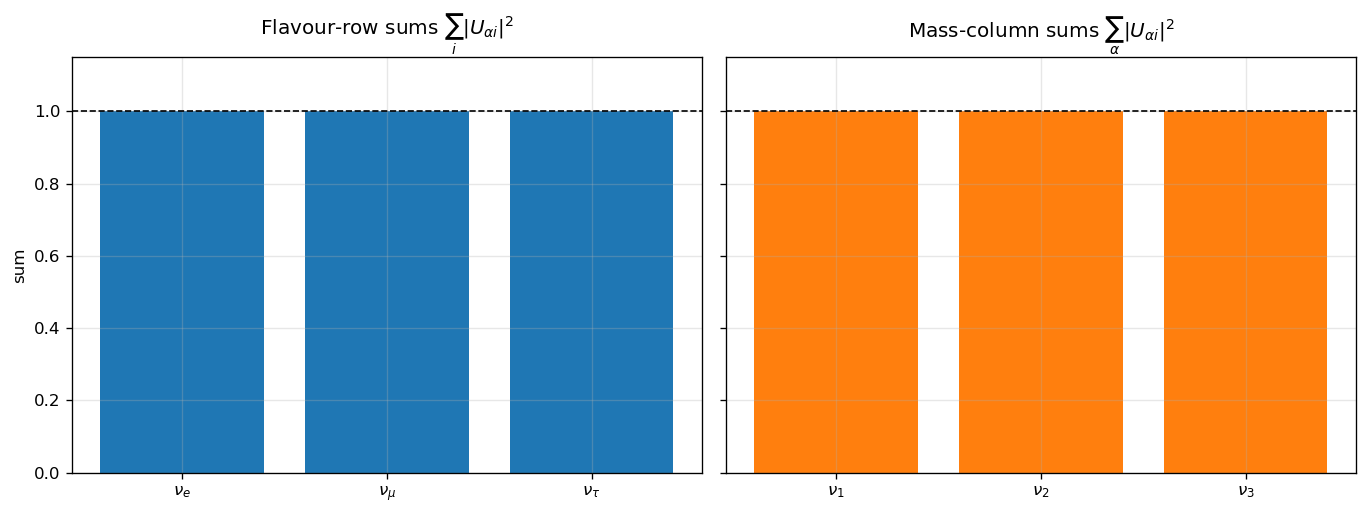

v:\output\diagnostic\core\diagnostic1_fig4_2_pmns_normalization.png
max row deviation   : 3.331e-16
max column deviation: 2.220e-16


In [57]:
row_sums = P_vac.sum(dim=1)
col_sums = P_vac.sum(dim=0)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4), sharey=True)
axes[0].bar(flavour_labels, to_numpy(row_sums), color="C0")
axes[0].axhline(1.0, color="black", linestyle="--", linewidth=1.0)
axes[0].set_title(r"Flavour-row sums $\sum_i |U_{\alpha i}|^2$")
axes[0].set_ylabel("sum")
axes[0].set_ylim(0.0, 1.15)

axes[1].bar(mass_labels, to_numpy(col_sums), color="C1")
axes[1].axhline(1.0, color="black", linestyle="--", linewidth=1.0)
axes[1].set_title(r"Mass-column sums $\sum_\alpha |U_{\alpha i}|^2$")
axes[1].set_ylim(0.0, 1.15)

fig.tight_layout()
save_and_show("diagnostic1_fig4_2_pmns_normalization.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print(f"max row deviation   : {float(torch.max(torch.abs(row_sums - 1.0))):.3e}")
print(f"max column deviation: {float(torch.max(torch.abs(col_sums - 1.0))):.3e}")


### 4.3 CP Phase and Jarlskog Invariant

The Jarlskog invariant measures genuine three-flavour CP violation. It is proportional to $\sin\delta_{CP}$ and vanishes in CP-conserving limits.

**Expected results:** $J(\delta_{CP})$ is sinusoidal, crosses zero at $0$, $\pi$, and $2\pi$, and changes sign under $\delta_{CP}\to-\delta_{CP}$.


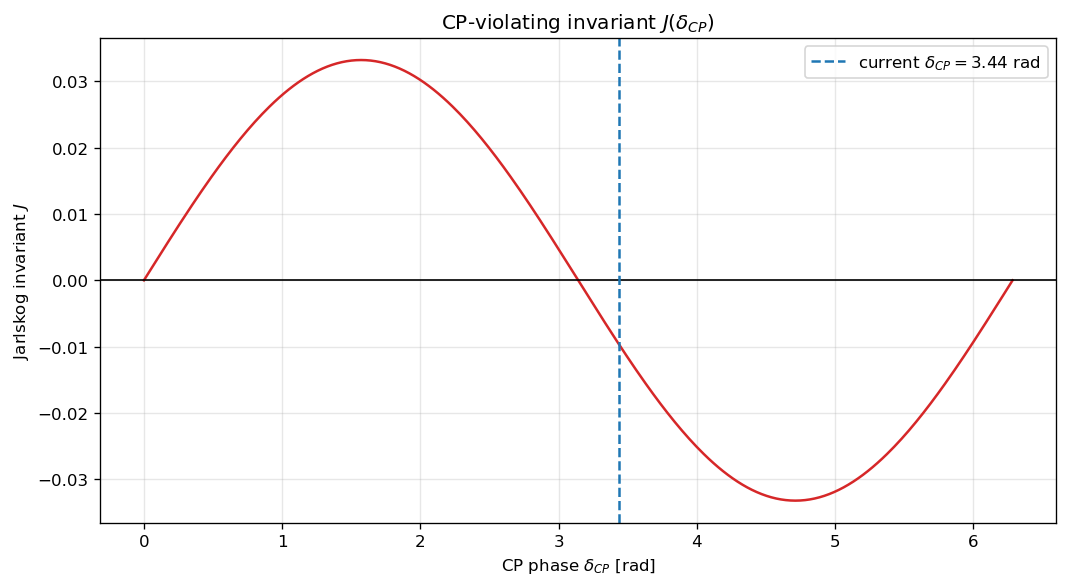

v:\output\diagnostic\core\diagnostic1_fig4_3_jarlskog_delta.png
Current delta_CP : 3.438299 rad
Current J        : -9.705931e-03
Max |J| scan     : 3.319723e-02


In [58]:
delta_grid = torch.linspace(0.0, 2.0 * math.pi, 361, device=ctx.device, dtype=ctx.dtype)
base = pmns.params
pmns_delta = PMNS_SM(
    PMNSParams(
        theta12=base.theta12.expand_as(delta_grid),
        theta13=base.theta13.expand_as(delta_grid),
        theta23=base.theta23.expand_as(delta_grid),
        delta=delta_grid,
        context=ctx,
    )
)
J_grid = pmns_delta.jarlskog_invariant()
J_current = pmns.jarlskog_invariant()
current_delta = float(base.delta.detach().cpu())

fig, ax = plt.subplots(figsize=(9.0, 5.0))
ax.plot(to_numpy(delta_grid), to_numpy(J_grid), color="C3")
ax.axhline(0.0, color="black", linewidth=1.0)
ax.axvline(current_delta, color="C0", linestyle="--", label=rf"current $\delta_{{CP}}={current_delta:.2f}$ rad")
ax.set_xlabel(r"CP phase $\delta_{CP}$ [rad]")
ax.set_ylabel(r"Jarlskog invariant $J$")
ax.set_title(r"CP-violating invariant $J(\delta_{CP})$")
ax.legend()
fig.tight_layout()
save_and_show("diagnostic1_fig4_3_jarlskog_delta.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print(f"Current delta_CP : {current_delta:.6f} rad")
print(f"Current J        : {float(J_current):.6e}")
print(f"Max |J| scan     : {float(torch.max(torch.abs(J_grid))):.6e}")


### 4.4 Electron-Row Interpretation

The first row of the PMNS projector has a simple analytic form. Varying $\theta_{12}$ redistributes $\nu_e$ between $\nu_1$ and $\nu_2$, while $\theta_{13}$ controls the small $\nu_3$ component.

**Expected results:** the bar chart matches the analytic expressions. In the angle scan, $|U_{e1}|^2$ decreases and $|U_{e2}|^2$ increases with $\theta_{12}$, while $|U_{e3}|^2$ remains fixed when $\theta_{13}$ is held fixed.


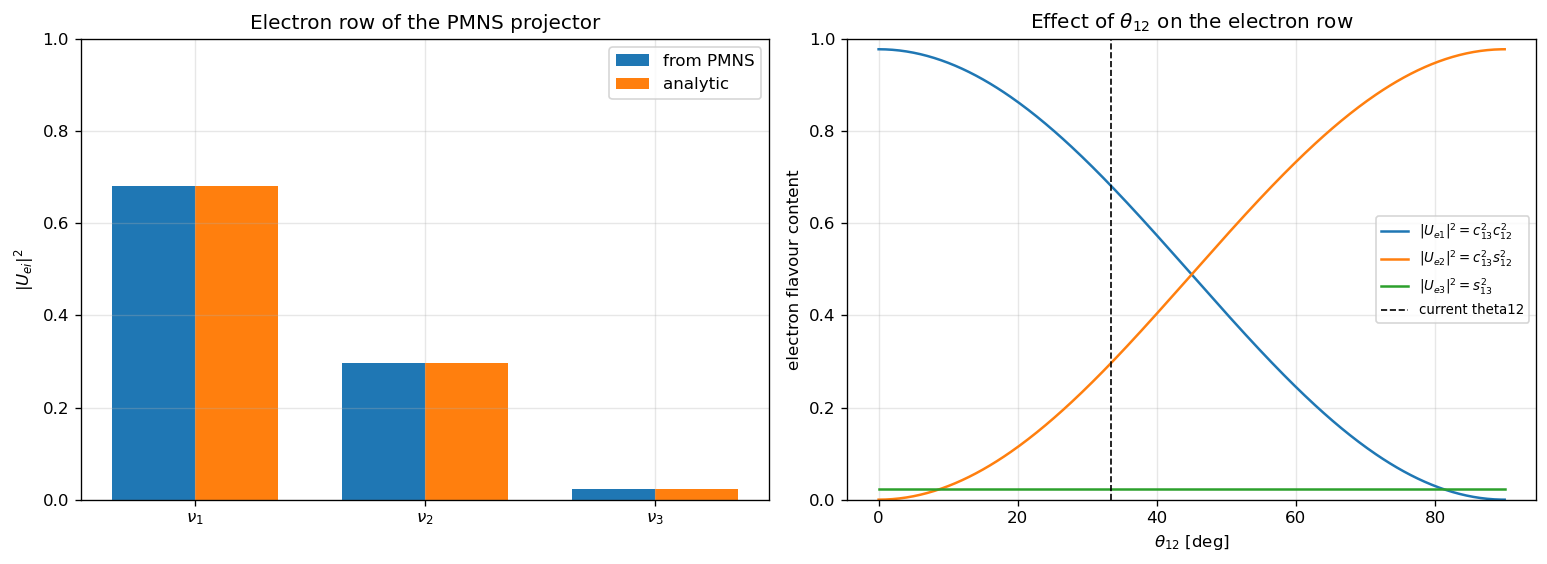

v:\output\diagnostic\core\diagnostic1_fig4_4_electron_row_pmns.png
PMNS electron row     : tensor([6.813011e-01, 2.964412e-01, 2.225771e-02], dtype=torch.float64)
Analytic electron row : tensor([6.813011e-01, 2.964412e-01, 2.225771e-02], dtype=torch.float64)
theta12 = 33.410 deg, theta13 = 8.580 deg


In [59]:
theta12 = base.theta12
theta13 = base.theta13
expected_e_row = torch.stack([
    torch.cos(theta13) ** 2 * torch.cos(theta12) ** 2,
    torch.cos(theta13) ** 2 * torch.sin(theta12) ** 2,
    torch.sin(theta13) ** 2,
])

th12_scan_deg = torch.linspace(0.0, 90.0, 361, device=ctx.device, dtype=ctx.dtype)
th12_scan = torch.deg2rad(th12_scan_deg)
ue1_scan = torch.cos(theta13) ** 2 * torch.cos(th12_scan) ** 2
ue2_scan = torch.cos(theta13) ** 2 * torch.sin(th12_scan) ** 2
ue3_scan = torch.full_like(th12_scan, torch.sin(theta13) ** 2)

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))
width = 0.36
x = np.arange(3)
axes[0].bar(x - width / 2, to_numpy(P_vac[0]), width=width, label="from PMNS")
axes[0].bar(x + width / 2, to_numpy(expected_e_row), width=width, label="analytic")
axes[0].set_xticks(x, mass_labels)
axes[0].set_ylim(0.0, 1.0)
axes[0].set_ylabel(r"$|U_{ei}|^2$")
axes[0].set_title("Electron row of the PMNS projector")
axes[0].legend()

axes[1].plot(to_numpy(th12_scan_deg), to_numpy(ue1_scan), label=r"$|U_{e1}|^2=c_{13}^2c_{12}^2$")
axes[1].plot(to_numpy(th12_scan_deg), to_numpy(ue2_scan), label=r"$|U_{e2}|^2=c_{13}^2s_{12}^2$")
axes[1].plot(to_numpy(th12_scan_deg), to_numpy(ue3_scan), label=r"$|U_{e3}|^2=s_{13}^2$")
axes[1].axvline(float(torch.rad2deg(theta12)), color="black", linestyle="--", linewidth=1.0, label="current theta12")
axes[1].set_xlabel(r"$\theta_{12}$ [deg]")
axes[1].set_ylabel(r"electron flavour content")
axes[1].set_ylim(0.0, 1.0)
axes[1].set_title(r"Effect of $\theta_{12}$ on the electron row")
axes[1].legend(fontsize=8)

fig.tight_layout()
save_and_show("diagnostic1_fig4_4_electron_row_pmns.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print("PMNS electron row     :", P_vac[0])
print("Analytic electron row :", expected_e_row)
print(f"theta12 = {float(torch.rad2deg(theta12)):.3f} deg, theta13 = {float(torch.rad2deg(theta13)):.3f} deg")


## 5. Hamiltonian

### 5.1 Kinetic and Matter Pieces in the Reduced Basis

The reduced Hamiltonian separates cleanly into a kinetic term, controlled by the mass splittings and PMNS reduced matrix, and a matter term, controlled by the electron density. The heatmaps below show the real parts of each piece and their sum for a representative energy and density.

**Expected results:** the matter Hamiltonian contributes only to the $(e,e)$ entry. The kinetic term contains off-diagonal structure from mixing. The full reduced Hamiltonian is the sum of both pieces and remains finite and Hermitian within numerical precision.


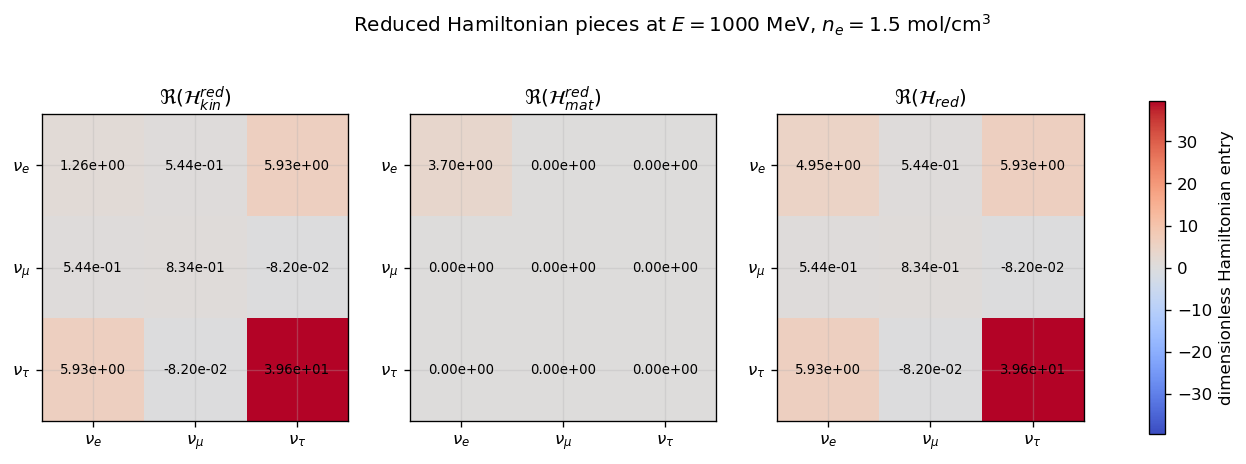

v:\output\diagnostic\core\diagnostic1_fig5_1_hamiltonian_reduced_pieces.png
Kinetic eigenvalues K_i: tensor([0.000000e+00, 1.196215e+00, 4.053572e+01], dtype=torch.float64)
Matter potential A     : 3.696386e+00
Hermiticity error      : 0.000e+00


In [60]:
H_ENERGY_MEV = torch.tensor(1000.0, device=ctx.device, dtype=ctx.dtype)
H_DENSITY_MOLCM3 = torch.tensor(1.5, device=ctx.device, dtype=ctx.dtype)

Hkin, KI_VECTOR = hamiltonian_kinetic_reduced(
    oscillation.DeltamSq21,
    oscillation.DeltamSq3l,
    H_ENERGY_MEV,
    pmns.reduced(),
    return_ki=True,
)
A_MATTER = matter_potential(H_DENSITY_MOLCM3, antinu=False, context=ctx)
Hmat = hamiltonian_matter_reduced(A_MATTER, context=ctx)
Hred = hamiltonian_reduced(oscillation, H_ENERGY_MEV, H_DENSITY_MOLCM3, context=ctx)

matrices = [Hkin.real, Hmat.real, Hred.real]
titles = [r"$\Re(\mathcal{H}_{kin}^{red})$", r"$\Re(\mathcal{H}_{mat}^{red})$", r"$\Re(\mathcal{H}_{red})$"]
max_abs = max(float(torch.max(torch.abs(m))) for m in matrices)

fig, axes = plt.subplots(1, 3, figsize=(14.0, 4.4))
for ax, matrix, title in zip(axes, matrices, titles):
    im = ax.imshow(to_numpy(matrix), cmap="coolwarm", vmin=-max_abs, vmax=max_abs)
    ax.set_xticks(range(3), flavour_labels)
    ax.set_yticks(range(3), flavour_labels)
    ax.set_title(title)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{float(matrix[i, j]):.2e}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=axes, shrink=0.82, label="dimensionless Hamiltonian entry")
fig.suptitle(rf"Reduced Hamiltonian pieces at $E={float(H_ENERGY_MEV):.0f}$ MeV, $n_e={float(H_DENSITY_MOLCM3):.1f}$ mol/cm$^3$")
save_and_show("diagnostic1_fig5_1_hamiltonian_reduced_pieces.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

hermitian_error = torch.max(torch.abs(Hred - Hred.conj().transpose(-2, -1)))
print("Kinetic eigenvalues K_i:", KI_VECTOR)
print(f"Matter potential A     : {float(A_MATTER):.6e}")
print(f"Hermiticity error      : {float(hermitian_error):.3e}")


### 5.2 Reduced versus Flavour Basis

The flavour-basis Hamiltonian is obtained by applying the PMNS basis transformation to the reduced Hamiltonian. This representation is the one directly associated with flavour amplitudes $(\nu_e,\nu_\mu,\nu_\tau)$.

**Expected results:** the flavour-basis Hamiltonian has the same eigenvalues as the reduced Hamiltonian up to numerical precision, because the transformation is unitary.


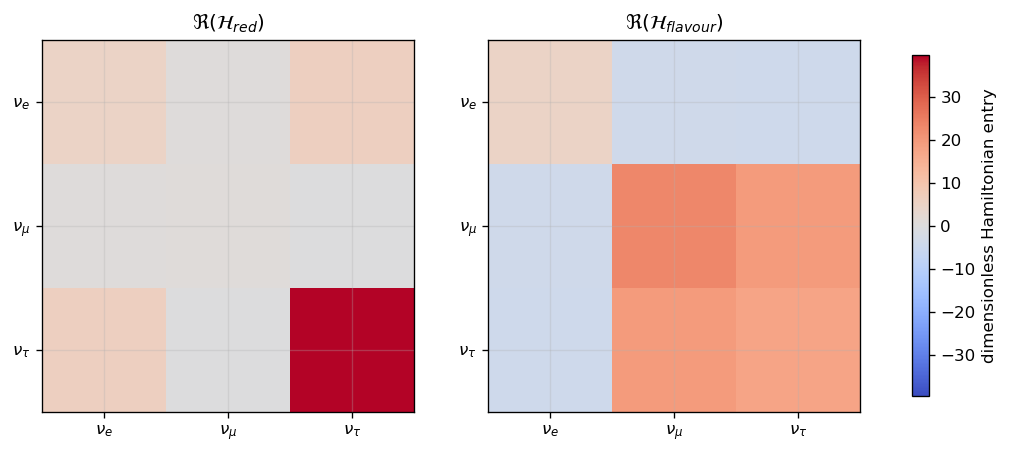

v:\output\diagnostic\core\diagnostic1_fig5_2_reduced_vs_flavour_basis.png
basis-transform max error: 0.000e+00
Eigenvalues reduced basis: tensor([7.399250e-01, 4.062288e+00, 4.062610e+01], dtype=torch.float64)
Eigenvalues flavour basis: tensor([7.399250e-01, 4.062288e+00, 4.062610e+01], dtype=torch.float64)
eigenvalue max difference: 1.421e-14


In [64]:
Hflav = hamiltonian_flavour(oscillation, H_ENERGY_MEV, H_DENSITY_MOLCM3, context=ctx)
Hflav_expected = pmns.H_flavour_basis(Hred, antinu=False, device=Hred.device, dtype=Hred.dtype)

eig_red = torch.linalg.eigvalsh(Hred)
eig_flav = torch.linalg.eigvalsh(Hflav)

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.5))
max_abs_basis = max(float(torch.max(torch.abs(Hred.real))), float(torch.max(torch.abs(Hflav.real))))
for ax, matrix, title in [
    (axes[0], Hred.real, r"$\Re(\mathcal{H}_{red})$"),
    (axes[1], Hflav.real, r"$\Re(\mathcal{H}_{flavour})$"),
]:
    im = ax.imshow(to_numpy(matrix), cmap="coolwarm", vmin=-max_abs_basis, vmax=max_abs_basis)
    ax.set_xticks(range(3), flavour_labels)
    ax.set_yticks(range(3), flavour_labels)
    ax.set_title(title)
fig.colorbar(im, ax=axes, shrink=0.82, label="dimensionless Hamiltonian entry")
#fig.tight_layout()
save_and_show("diagnostic1_fig5_2_reduced_vs_flavour_basis.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print(f"basis-transform max error: {float(torch.max(torch.abs(Hflav - Hflav_expected))):.3e}")
print("Eigenvalues reduced basis:", eig_red)
print("Eigenvalues flavour basis:", eig_flav)
print(f"eigenvalue max difference: {float(torch.max(torch.abs(eig_red - eig_flav))):.3e}")


### 5.3 Energy Dependence of Hamiltonian Scales

At fixed density, the matter term is independent of energy while the kinetic term scales as $1/E$. This plot shows the Frobenius norms of the kinetic and matter Hamiltonian pieces as a function of energy.

**Expected results:** the kinetic norm decreases as $1/E$, the matter norm is flat, and the ratio $\|H_{mat}\|/\|H_{kin}\|$ grows approximately linearly with energy.


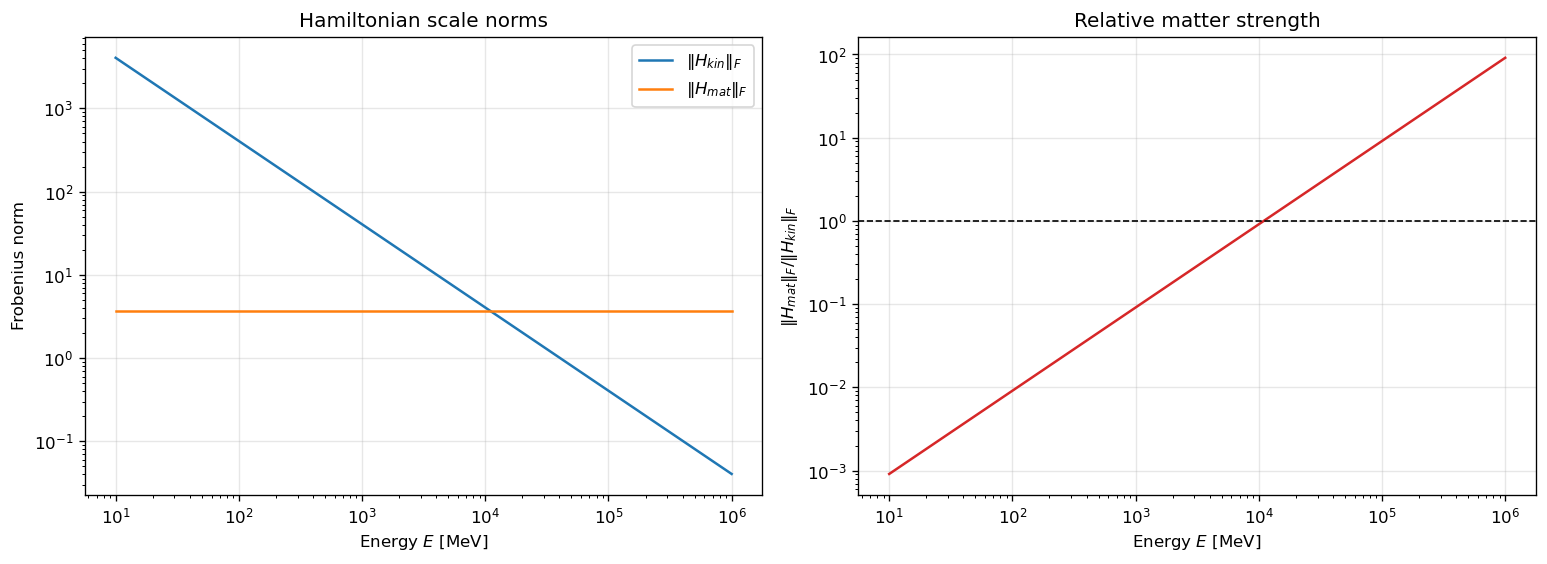

v:\output\diagnostic\core\diagnostic1_fig5_3_hamiltonian_energy_scaling.png
Approximate norm crossing energy: 1.109463e+04 MeV
ratio at 1 GeV: 9.220680e-02


In [62]:
energy_scan = torch.logspace(1.0, 6.0, 400, device=ctx.device, dtype=ctx.dtype)
Hkin_scan = hamiltonian_kinetic_reduced(
    oscillation.DeltamSq21,
    oscillation.DeltamSq3l,
    energy_scan,
    pmns.reduced(),
)
Hmat_scan = hamiltonian_matter_reduced(
    matter_potential(H_DENSITY_MOLCM3, antinu=False, context=ctx).expand_as(energy_scan),
    context=ctx,
)
kin_norm = torch.linalg.matrix_norm(Hkin_scan)
mat_norm = torch.linalg.matrix_norm(Hmat_scan)
ratio_norm = mat_norm / kin_norm

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))
axes[0].loglog(to_numpy(energy_scan), to_numpy(kin_norm), label=r"$\|H_{kin}\|_F$")
axes[0].loglog(to_numpy(energy_scan), to_numpy(mat_norm), label=r"$\|H_{mat}\|_F$")
axes[0].set_xlabel(r"Energy $E$ [MeV]")
axes[0].set_ylabel("Frobenius norm")
axes[0].set_title("Hamiltonian scale norms")
axes[0].legend()

axes[1].loglog(to_numpy(energy_scan), to_numpy(ratio_norm), color="C3")
axes[1].axhline(1.0, color="black", linestyle="--", linewidth=1.0)
axes[1].set_xlabel(r"Energy $E$ [MeV]")
axes[1].set_ylabel(r"$\|H_{mat}\|_F/\|H_{kin}\|_F$")
axes[1].set_title("Relative matter strength")
fig.tight_layout()
save_and_show("diagnostic1_fig5_3_hamiltonian_energy_scaling.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

idx_cross = torch.argmin(torch.abs(torch.log10(ratio_norm)))
print(f"Approximate norm crossing energy: {float(energy_scan[idx_cross]):.6e} MeV")
print(f"ratio at 1 GeV: {float(ratio_norm[torch.argmin(torch.abs(energy_scan - 1000.0))]):.6e}")


### 5.4 Neutrino versus Antineutrino Matter Sign

For antineutrinos, the matter potential changes sign. In the Standard Model reduced matrix used here, the kinetic piece is unchanged by complex conjugation because $U_{red}=R_{13}R_{12}$ is real, so the visible difference in the reduced Hamiltonian is the sign of the matter contribution.

**Expected results:** the difference $H_{\bar\nu}^{red}-H_{\nu}^{red}$ is concentrated in the electron-flavour diagonal entry and equals approximately $-2A$ there.


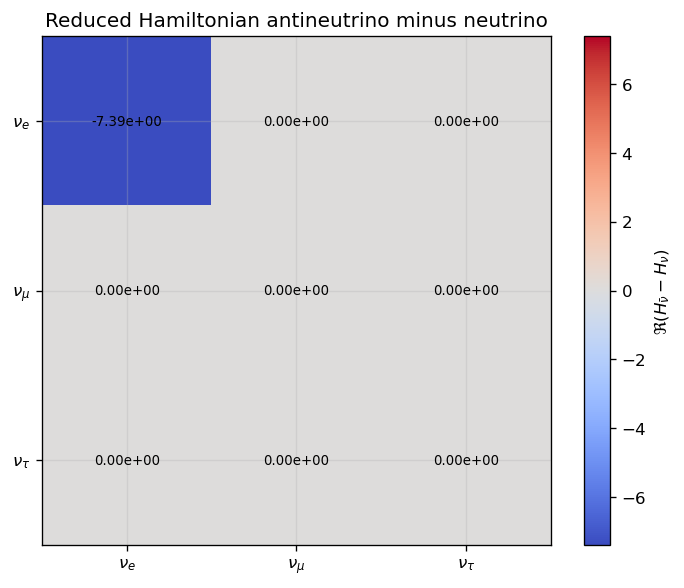

v:\output\diagnostic\core\diagnostic1_fig5_4_hamiltonian_antinu_difference.png
A neutrino              : 3.696386e+00
Expected delta H_ee     : -7.392771e+00
Observed delta H_ee     : -7.392771e+00


In [63]:
oscillation_anti = OscillationParameters.from_preset("_SM_NUFIT52_NO", antinu=True, context=ctx)
Hred_anti = hamiltonian_reduced(oscillation_anti, H_ENERGY_MEV, H_DENSITY_MOLCM3, context=ctx)
Hdiff = Hred_anti - Hred

fig, ax = plt.subplots(figsize=(6.2, 5.0))
max_abs_diff = float(torch.max(torch.abs(Hdiff.real)))
im = ax.imshow(to_numpy(Hdiff.real), cmap="coolwarm", vmin=-max_abs_diff, vmax=max_abs_diff)
fig.colorbar(im, ax=ax, label=r"$\Re(H_{\bar\nu}-H_\nu)$")
ax.set_xticks(range(3), flavour_labels)
ax.set_yticks(range(3), flavour_labels)
ax.set_title(r"Reduced Hamiltonian antineutrino minus neutrino")
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{float(Hdiff.real[i, j]):.2e}", ha="center", va="center", fontsize=8)
fig.tight_layout()
save_and_show("diagnostic1_fig5_4_hamiltonian_antinu_difference.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print(f"A neutrino              : {float(A_MATTER):.6e}")
print(f"Expected delta H_ee     : {-2.0 * float(A_MATTER):.6e}")
print(f"Observed delta H_ee     : {float(Hdiff.real[0, 0]):.6e}")


## 6. Summary

This notebook separates the visual diagnostics from the automated pytest checks.

| Quantity | Diagnostic result | Physical interpretation |
|----------|-------------------|-------------------------|
| Matter potential $A$ | Linear in $n_e$ | The MSW charged-current scale is set by the local electron density. |
| Antineutrino sign | $A_{\bar\nu}=-A_\nu$ | Matter effects reverse sign for antineutrinos. |
| Kinetic potential $K_i$ | $K_i\propto\Delta m_i^2/E$ | Vacuum oscillation phases decrease with energy. |
| Matter/kinetic ratio | $|A/K|\propto E$ at fixed density | Matter effects become relatively more important at high energy. |
| Evolution scale $L_0$ | Both $A$ and $K_i$ scale linearly | The Hamiltonian is dimensionless and must be paired with $x=L/L_0$. |
| PMNS projector $|U_{\alpha i}|^2$ | Doubly stochastic | Flavour and mass probabilities are normalized by unitarity. |
| Jarlskog invariant $J$ | Sinusoidal in $\delta_{CP}$ | CP violation is controlled by a rephasing-invariant quantity. |
| Reduced Hamiltonian | $H_{kin}+H_{mat}$ | Kinetic mixing and matter potential combine into the propagation generator. |
| Flavour Hamiltonian | Same eigenvalues as reduced basis | The basis change is unitary and preserves the physical spectrum. |
| Legacy prefactor | Small constant relative offset | Useful only for bit-comparable validation against the legacy Peanuts implementation. |

**Physical interpretation:** the Core Hamiltonian starts from two scalar ingredients. The kinetic term carries the vacuum mass-splitting physics and falls as $1/E$, while the matter term carries the coherent electron-background effect and is independent of energy for a fixed medium. Their relative size determines whether propagation is vacuum-like or matter-dominated. The PMNS section then shows how flavour states are distributed over mass eigenstates and where the CP phase enters. The Hamiltonian section combines those ingredients into the propagation generator and verifies basis equivalence. The next natural diagnostics are evolution-operator unitarity and full propagation.
